# Anáise de Temperatura - Brasília

Esse projeto analisa dados históricos de temperatura de Brasília (Maio - Agosto 2026), usando a API Open-Meteo. O intuito geral é aprimorar e aprofundar meu conhecimento com Python em sua forma analítica e nas bibliotecas disponíveis.

## 1. Coleta de Dados

Dados obtidos via API Open-Meteo (endpoint `archive`), para o período de 27/05/2026 a 12/08/2026 (78 dias), em Brasília (latitude -15.7875, longitude -47.975).

In [95]:
import pandas as pd
import requests

resposta = requests.get("https://archive-api.open-meteo.com/v1/archive?latitude=-15.7875&longitude=-47.975&timezone=America%2FSao_Paulo&start_date=2026-05-27&end_date=2026-08-12&hourly=temperature_2m")

print(resposta.status_code)
if resposta.status_code == 200:
    dados = resposta.json()
    print(dados.keys())
else:
    print(f"Erro: {resposta.status_code}")

print(dados["hourly"].keys())
print(len(dados["hourly"]["time"]))

200
dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])
dict_keys(['time', 'temperature_2m'])
1872


## 2. Preparação dos Dados

Após a coleta, os dados foram validados (0 valores faltantes, 1872 registros = 78 dias × 24h) e a coluna de tempo convertida para o tipo datetime, permitindo extrair hora, dia e mês para as análises seguintes.

In [96]:
df = pd.DataFrame({
    "time": dados["hourly"]["time"],
    "temperature_2m": dados["hourly"]["temperature_2m"]
})

display(df["temperature_2m"].isna().sum())
display(len(df))

#display(df.head())
#display(df.dtypes)
#display(df.tail())
#df_com_dados = df[df["temperature_2m"].notna()]
#display(df_com_dados["time"].min())

df["time"] = pd.to_datetime(df["time"])
df["hora"] = df["time"].dt.hour
df["dia"] = df["time"].dt.date

print(df.dtypes)
display(df.head())

np.int64(0)

1872

time              datetime64[ns]
temperature_2m           float64
hora                       int32
dia                       object
dtype: object


,time,temperature_2m,hora,dia
0,2026-05-27 00:00:00,18.9,0,2026-05-27
1,2026-05-27 01:00:00,18.3,1,2026-05-27
2,2026-05-27 02:00:00,17.7,2,2026-05-27
3,2026-05-27 03:00:00,17.4,3,2026-05-27
4,2026-05-27 04:00:00,17.0,4,2026-05-27


## 3. Análises
### 3.1 Ciclo Diário de Temperatura

Temperatura média por hora do dia, revelando o padrão de aquecimento e resfriamento ao longo de 24h.

In [ ]:

temp_por_hora = df.groupby("hora")["temperature_2m"].mean()
display(temp_por_hora)

hora
0     18.474359
1     17.951282
2     17.485897
3     16.780769
4     16.564103
5     16.212821
6     15.916667
7     15.929487
8     17.933333
9     20.378205
10    22.398718
11    23.935897
12    25.011538
13    25.655128
14    25.926923
15    26.069231
16    25.682051
17    24.870513
18    23.383333
19    22.320513
20    21.430769
21    20.410256
22    19.767949
23    19.128205
Name: temperature_2m, dtype: float64

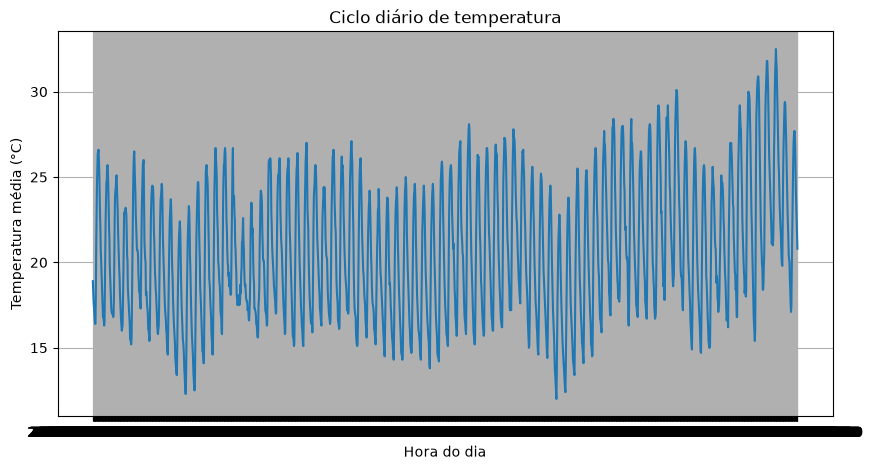

In [ ]:
#DADO BRUTO
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df["time"], df["temperature_2m"])
plt.xlabel('Hora do dia')
plt.ylabel('Temperatura média (°C)')
plt.title('Ciclo diário de temperatura')
plt.grid(True)
plt.show()

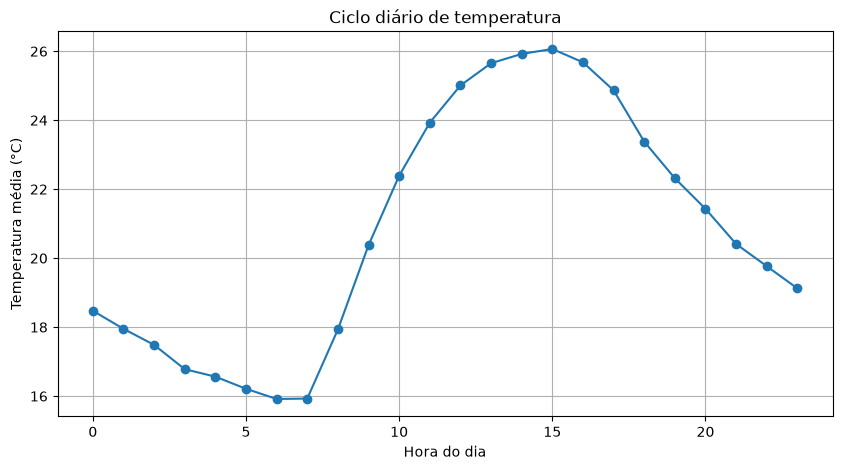

In [ ]:
#DADO DIARIO
plt.figure(figsize=(10, 5))
plt.plot(temp_por_hora.index, temp_por_hora.values, marker='o')
plt.xlabel('Hora do dia')
plt.ylabel('Temperatura média (°C)')
plt.title('Ciclo diário de temperatura')
plt.grid(True)
plt.show()

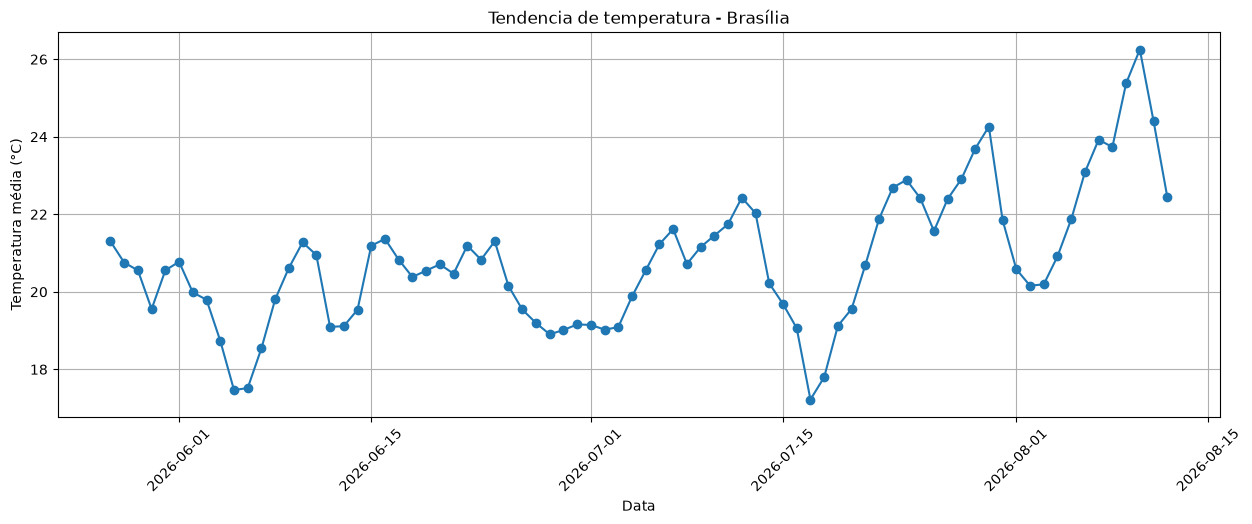

In [ ]:
#MEDIA DIARIA
temp_por_dia = df.groupby("dia")["temperature_2m"].mean()

plt.figure(figsize=(15, 5))
plt.plot(temp_por_dia.index, temp_por_dia.values, marker='o')
plt.xlabel("Data")
plt.ylabel("Temperatura média (°C)")
plt.title("Tendencia de temperatura - Brasília")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

### 3.2 Amplitude Térmica e Tendência Geral

Temperatura mínima, média e máxima diária ao longo dos 78 dias, mostrando a transição de outono para inverno (junho) e o início do aquecimento em agosto.

,min,max,mean
dia,,,
2026-05-27,16.4,26.6,21.300000
2026-05-28,16.3,25.7,20.754167
2026-05-29,16.8,25.1,20.554167
2026-05-30,16.0,23.2,19.554167
2026-05-31,15.2,26.5,20.554167


,min,max,mean,amplitude
dia,,,,
2026-05-27,16.4,26.6,21.300000,10.2
2026-05-28,16.3,25.7,20.754167,9.4
2026-05-29,16.8,25.1,20.554167,8.3
2026-05-30,16.0,23.2,19.554167,7.2
2026-05-31,15.2,26.5,20.554167,11.3


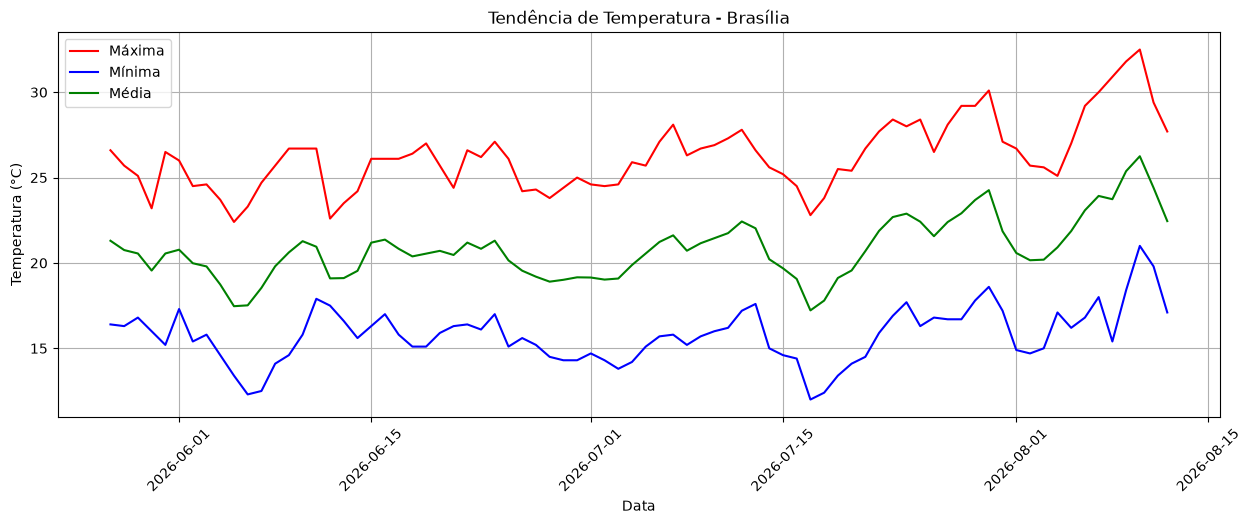

In [ ]:
temp_diaria = df.groupby("dia")["temperature_2m"].agg(["min", "max", "mean"])
display(temp_diaria.head())

temp_diaria["amplitude"] = temp_diaria["max"] - temp_diaria["min"]
display(temp_diaria.head())

plt.figure(figsize=(15, 5))
plt.plot(temp_diaria.index, temp_diaria["max"], label="Máxima", color="red")
plt.plot(temp_diaria.index, temp_diaria["min"], label="Mínima", color="blue")
plt.plot(temp_diaria.index, temp_diaria["mean"], label="Média", color="green")
plt.xlabel("Data")
plt.ylabel("Temperatura (°C)")
plt.title("Tendência de Temperatura - Brasília")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


In [ ]:
#media por mes
df["mes"] = df["time"].dt.month
temp_por_mes = df.groupby("mes")["temperature_2m"].mean()
print(df.groupby('mes')['dia'].nunique())
display(temp_por_mes)

mes
5     5
6    30
7    31
8    12
Name: dia, dtype: int64


mes
5    20.543333
6    19.932917
7    20.966532
8    22.744444
Name: temperature_2m, dtype: float64

### 3.3 Tendência Mensal (Junho x Julho)

Comparação entre os dois únicos meses completos no período coletado, isolando o efeito de meses parciais (maio e agosto).

In [ ]:
df_jun_jul = df[df["mes"].isin([6, 7])]
temp_jun_jul = df_jun_jul.groupby("mes")["temperature_2m"].agg(["min", "max", "mean"])
display(temp_jun_jul)

,min,max,mean
mes,,,
6,12.3,27.1,19.932917
7,12.0,30.1,20.966532


## 4. Conclusão

- O ciclo diário mostra mínima por volta das 6h (~15.9°C) e máxima por volta das 15h (~26.1°C), com atraso térmico típico em relação ao horário de maior incidência solar.
- Comparando os dois meses completos do período (junho e julho), houve aumento na temperatura máxima (27.1°C → 30.1°C), enquanto a mínima permaneceu estável (~12°C) — indicando que o aquecimento de inverno para o início da primavera se concentra nas tardes, não nas noites.
- Limitação: os dados de maio e agosto no dataset são parciais (5 e 12 dias, respectivamente), por isso a comparação mensal foi restrita a junho e julho, os únicos meses completos disponíveis.